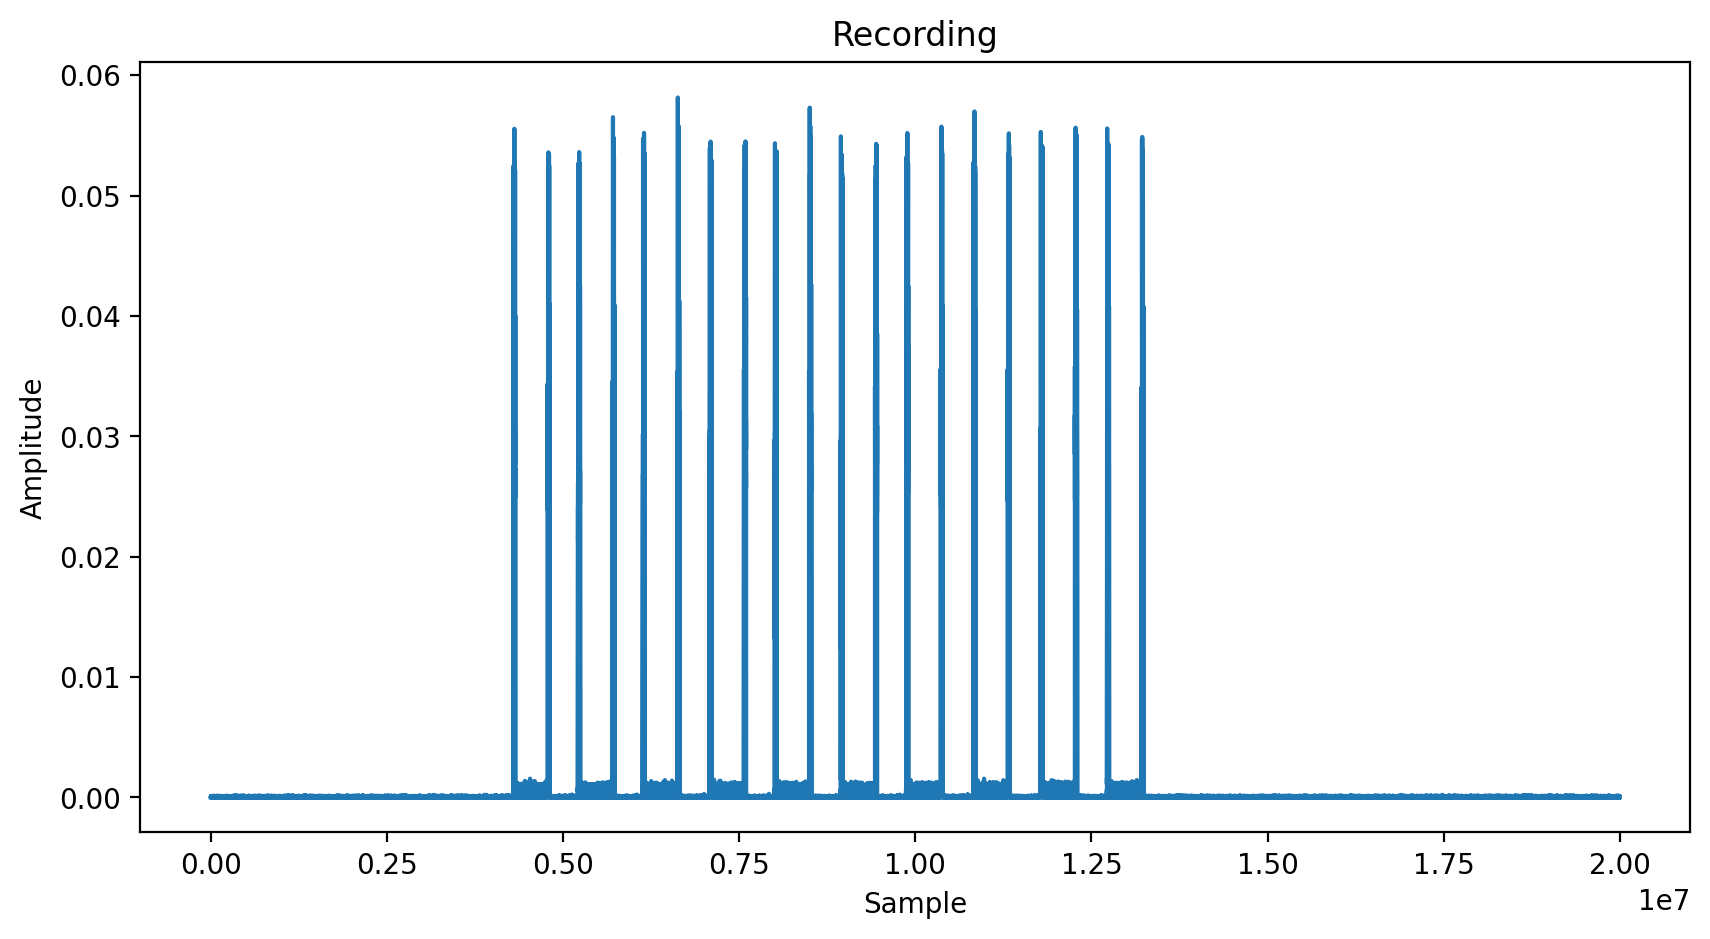

(19998800,) (99994, 200)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal

import sys 
sys.path.append('../..')
from src import CONFIG

conf = CONFIG()

fltr = scipy.signal.butter(30, conf.LPF_CUTOFF, 'low', analog=False, output='sos',fs=conf.RX_RATE)
def butter(input):
    global fltr
    return scipy.signal.sosfilt(fltr, input) 


batch_size = 20000
file = 'destination_1900000000.0_5000000.0_50.0_4.0_False_.iq'


recording = np.fromfile(file, dtype=np.complex64)
plt.figure(figsize=(10, 5), dpi=200)
plt.plot(np.abs(butter(recording))**2)
plt.title('Recording')
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.show()

#divide the recording into the batches of batch_size but the las batch can be anysize
batch_size = 200
if recording.size % batch_size != 0:
    recording = np.concatenate((recording, np.zeros(batch_size - recording.size % batch_size)))
recording_batches = recording.reshape(-1, batch_size)

print(recording.shape, recording_batches.shape)

# now I want to process the recording in batches


In [ ]:
res = []
State = 0
threshold = (np.max(np.abs(butter(recording)))**2) * 0.3


# fft = np.fft.fftshift(np.fft.fft(recording_batches, axis=1))
# Calculate the frequency axis
freq_axis = np.fft.fftshift(np.fft.fftfreq(batch_size, d=1/5e6))

# Find indices corresponding to -300kHz and 300kHz
lower_bound = np.where(freq_axis >= -300e3)[0][0]
upper_bound = np.where(freq_axis <= 300e3)[0][-1]

print("lower_bound: ", lower_bound)
print("upper_bound: ", upper_bound)




energy_ratio = []
for i in range(recording_batches.shape[0]):


    batch = recording_batches[i].copy()

    bathc_power = np.max(np.abs(butter(batch))**2)
    # process the batch
    fft = np.fft.fftshift(np.fft.fft(batch))

        # Compute energy in the band of interest (-300kHz to 300kHz)
    energy_band = np.sum(np.abs(fft[lower_bound:upper_bound])**2)

    # Compute energy in the rest of the band
    energy_rest = np.sum(np.abs(fft)**2) - energy_band

    # Compare energies
    energy_ratio.append( energy_band / energy_rest)




    if State == 0: # Wait for the rising edge of the begining burst
        # check if we received a burst
        if  bathc_power> threshold and energy_ratio[-1] > 4:
            State = 1
            res.extend(batch)
        else:
            # we are still in the noise state, so we can insert some zeros
            res.extend([np.nan + 1j*np.nan])
    elif State == 1: # Wait for the falling edge of the begining burst
        # we are detecting the falling edge
        if bathc_power < threshold:
            State = 2
        res.extend(batch)

    elif State == 2: # Wait for the rising edge of the ending burst
        if bathc_power > threshold:
            State = 3
        res.extend(batch)
    elif State == 3: # Wait for the falling edge of the ending burst
        if bathc_power < threshold:
            # we have a signal, but it is below the threshold, so we stop recording
            State = 0
        res.extend(batch)


from itertools import groupby
from operator import itemgetter

frames = {}
cnt = 0
test_list = np.where(~np.isnan(res))
for k, g in groupby(enumerate(test_list[0]), lambda ix: ix[0]-ix[1]):
    temp = list(map(itemgetter(1), g))
    if len(temp)< 10:
        continue 
    frames[cnt] = np.array(res[temp[0]:  temp[-1]])
    cnt = cnt + 1


print(len(frames))



     

lower_bound:  89
upper_bound:  111
10


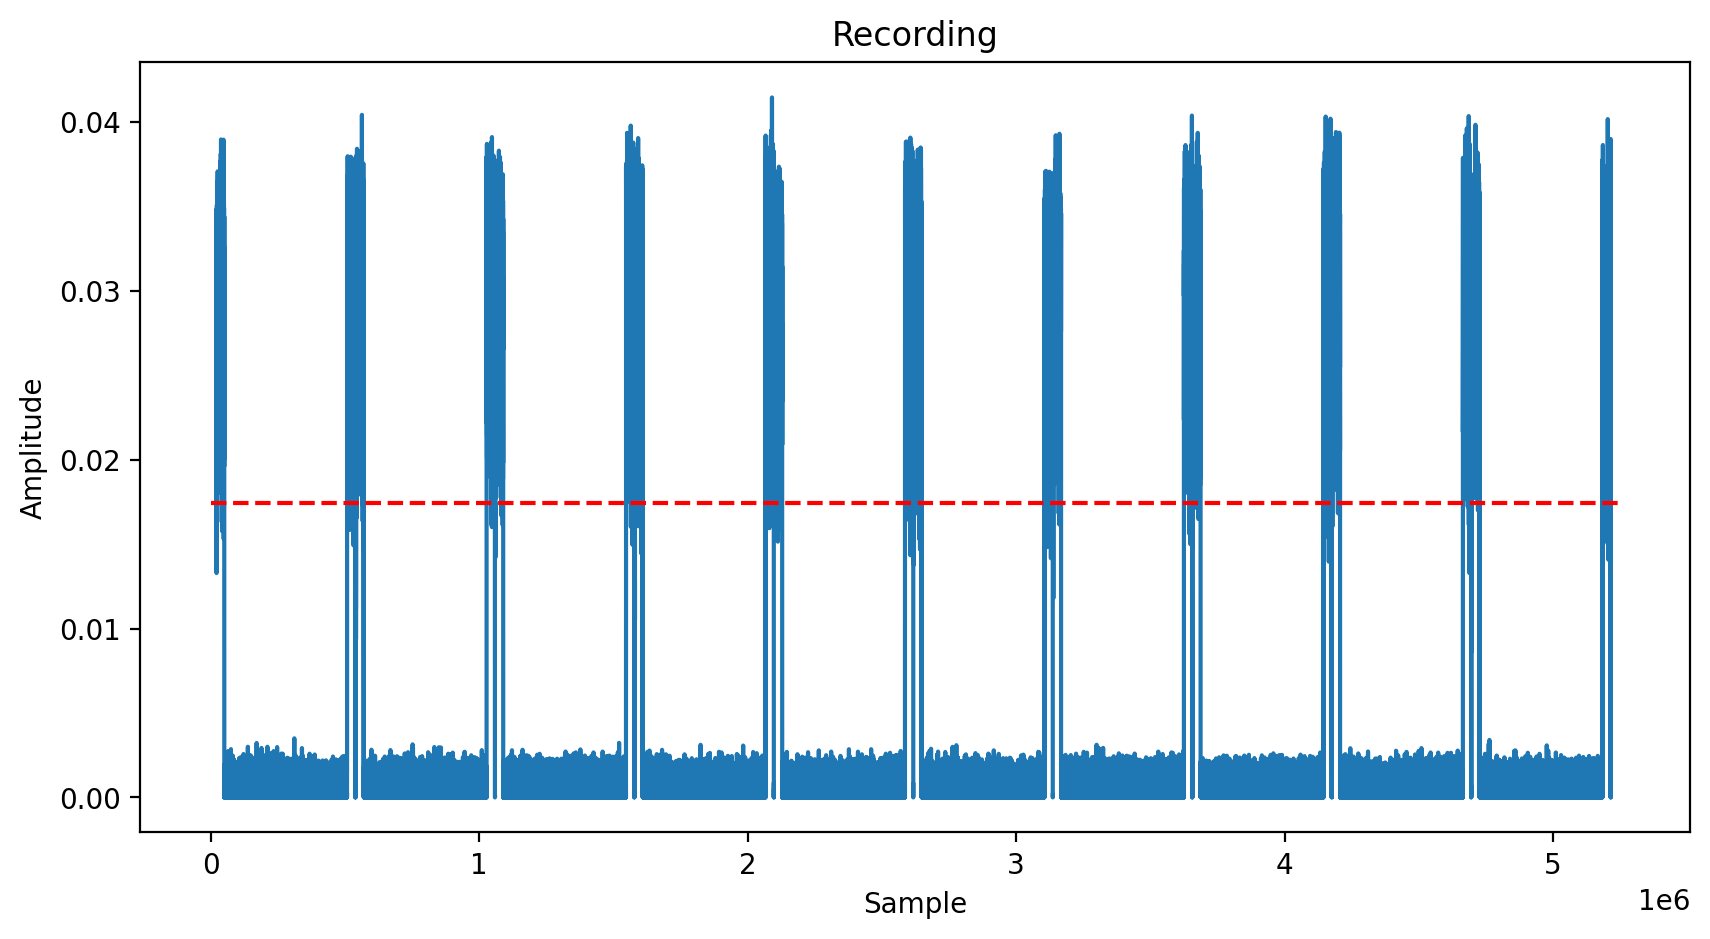

In [3]:

# At the end the res should contain the signal and replace the noise with 0. And also it should work for any batch size
plt.figure(figsize=(10, 5), dpi=200)
plt.plot(np.abs(res)**2)
plt.title('Recording')
plt.hlines(threshold, 0, len(res), colors='r', linestyles='dashed')

plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.show()

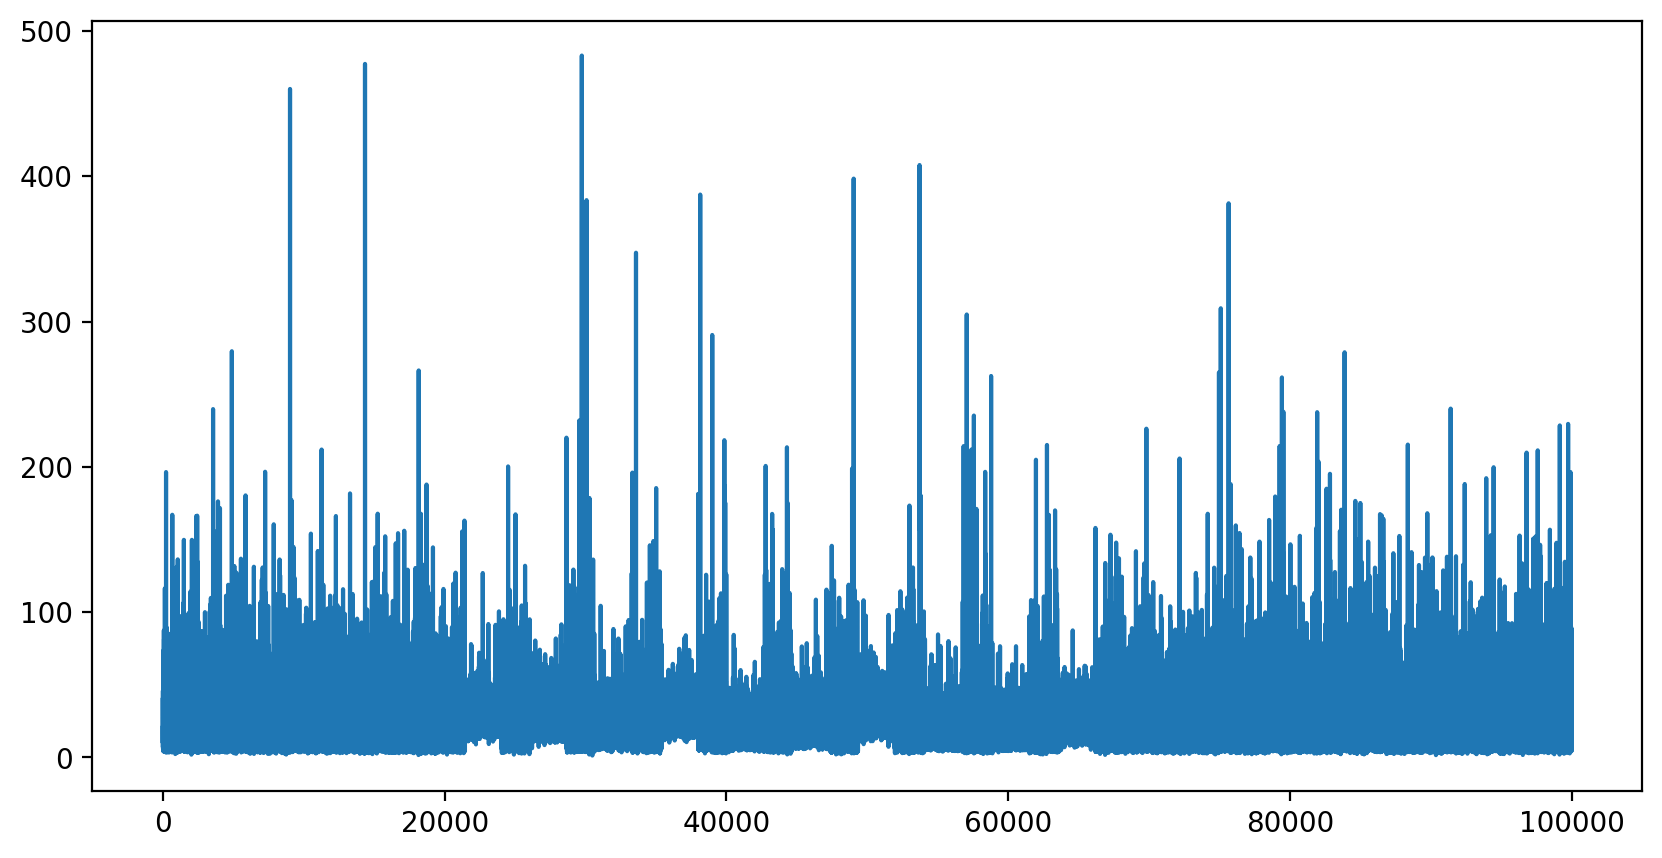

In [4]:
plt.figure(figsize=(10, 5), dpi=200)
plt.plot(energy_ratio)

In [5]:
from src.rx import Demodulation
from src import  utils

demod = Demodulation(conf)
for frame in frames:
    hard_decision,rs, SNR = demod.decode(frames[frame])
    index = demod.detect_message_indices(received=list(hard_decision), preamble=conf.PREAMBLE, postamble=conf.POSTAMBLE, repeat=conf.PREAMBLE_REPEAT)
    msg_str = utils.bits_to_string(hard_decision[index[0]:index[1]])
    print(msg_str)

This message is the default payload for the tests, and is 1088 bits long. It will be superposed with MAC tag of 256 bits with Rate= 1/3?This message is the default payload for the tests, and is 1088 bits long. It will be superposed with MAC tag of 256 bits with Rate= 1/3?This message i
This message is the default payload for the tests, and is 1088 bits long. It will be superposed with MAC tag of 256 bits with Rate= 1/3?This message is the default payload for the tests, and is 1088 bits long. It will be superposed with MAC tag of 256 bits with Rate= 1/3?This message i
This message is the default payload for the tests, and is 1088 bits long. It will be superposed with MAC tag of 256 bits with Rate= 1/3?This message is the default payload for the tests, and is 1088 bits long. It will be superposed with MAC tag of 256 bits with Rate= 1/3?This message i
This message is the default payload for the tests, and is 1088 bits long. It will be superposed with MAC tag of 256 bits with Rate= 1/3?Thi